# Retrain Epoch Ablation Analysis

Analyzes how the number of retraining epochs affects Infusion effectiveness.

Compares: 9→10 (1 epoch), 8→10 (2 epochs), ..., 0→10 (full retrain from scratch).

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Load results
results_dir = '/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/cifar/results/retrain_ablation/'
log_path = os.path.join(results_dir, 'retrain_ablation_log.jsonl')

results = []
if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        for line in f:
            results.append(json.loads(line))
    print(f"Loaded {len(results)} results")
else:
    print(f"No results file found at {log_path}")

df = pd.DataFrame(results)
df.head()

Loaded 10 results


,sample_idx,test_image_idx,true_label,target_class,start_epoch,n_retrain_epochs,prob_target_original,prob_target_infused,delta_prob,timestamp
0,0,9031,0,1,9,1,0.000056,0.006980,0.006924,2026-01-18T18:01:24.451064
1,0,9031,0,1,8,2,0.000056,0.011423,0.011367,2026-01-18T18:01:48.725442
2,0,9031,0,1,7,3,0.000056,0.019721,0.019665,2026-01-18T18:02:26.292376
3,0,9031,0,1,6,4,0.000056,0.033971,0.033915,2026-01-18T18:03:15.215948
4,0,9031,0,1,5,5,0.000056,0.021053,0.020997,2026-01-18T18:04:17.222108


In [3]:
# Check progress
if len(df) > 0:
    n_samples = df['sample_idx'].nunique()
    n_epochs = df['start_epoch'].nunique()
    print(f"Unique samples: {n_samples}")
    print(f"Start epochs tested: {sorted(df['start_epoch'].unique())}")
    print(f"Total results: {len(df)} ({n_samples} samples × {n_epochs} epochs)")

Unique samples: 1
Start epochs tested: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Total results: 10 (1 samples × 10 epochs)


In [4]:
# Compute summary statistics by start_epoch
if len(df) > 0:
    summary = df.groupby('start_epoch').agg({
        'delta_prob': ['mean', 'std', 'median', 'count'],
        'n_retrain_epochs': 'first'
    }).round(4)
    summary.columns = ['mean', 'std', 'median', 'count', 'n_retrain_epochs']
    summary = summary.sort_index(ascending=False)  # 9, 8, 7, ..., 0
    print(summary)

               mean  std  median  count  n_retrain_epochs
start_epoch                                              
9            0.0069  NaN  0.0069      1                 1
8            0.0114  NaN  0.0114      1                 2
7            0.0197  NaN  0.0197      1                 3
6            0.0339  NaN  0.0339      1                 4
5            0.0210  NaN  0.0210      1                 5
4            0.0315  NaN  0.0315      1                 6
3            0.0275  NaN  0.0275      1                 7
2            0.0422  NaN  0.0422      1                 8
1            0.0476  NaN  0.0476      1                 9
0            0.0006  NaN  0.0006      1                10


Saved figure to /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/cifar/results/retrain_ablation/retrain_ablation_plot.png


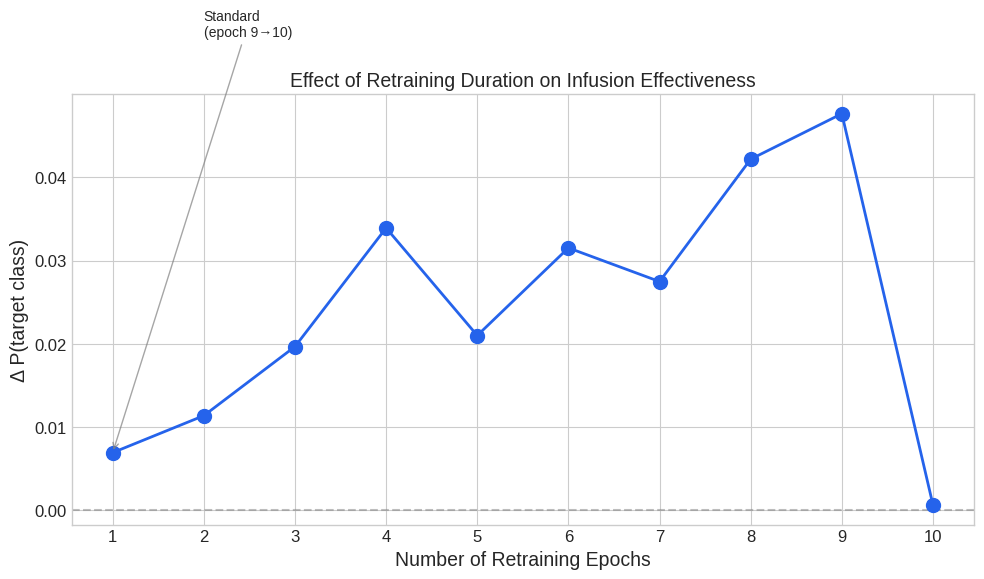

In [5]:
# Main figure: Delta prob vs number of retraining epochs
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Group by n_retrain_epochs and compute stats
    stats = df.groupby('n_retrain_epochs')['delta_prob'].agg(['mean', 'std', 'count']).reset_index()
    stats = stats.sort_values('n_retrain_epochs')
    
    # Compute standard error
    stats['se'] = stats['std'] / np.sqrt(stats['count'])
    
    # Plot with error bars
    ax.errorbar(
        stats['n_retrain_epochs'], 
        stats['mean'], 
        yerr=stats['se'] * 1.96,  # 95% CI
        fmt='o-', 
        capsize=5, 
        capthick=2,
        markersize=10,
        linewidth=2,
        color='#2563eb'
    )
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # Labels
    ax.set_xlabel('Number of Retraining Epochs', fontsize=14)
    ax.set_ylabel('Δ P(target class)', fontsize=14)
    ax.set_title('Effect of Retraining Duration on Infusion Effectiveness', fontsize=14)
    
    # Set x-ticks to integers
    ax.set_xticks(stats['n_retrain_epochs'].values)
    
    # Add annotation for standard (1 epoch)
    std_row = stats[stats['n_retrain_epochs'] == 1]
    if len(std_row) > 0:
        ax.annotate(
            'Standard\n(epoch 9→10)',
            xy=(1, std_row['mean'].values[0]),
            xytext=(2, std_row['mean'].values[0] + 0.05),
            fontsize=10,
            ha='left',
            arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7)
        )
    
    plt.tight_layout()
    
    # Save figure
    fig_path = os.path.join(results_dir, 'retrain_ablation_plot.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Saved figure to {fig_path}")
    
    plt.show()

Saved figure


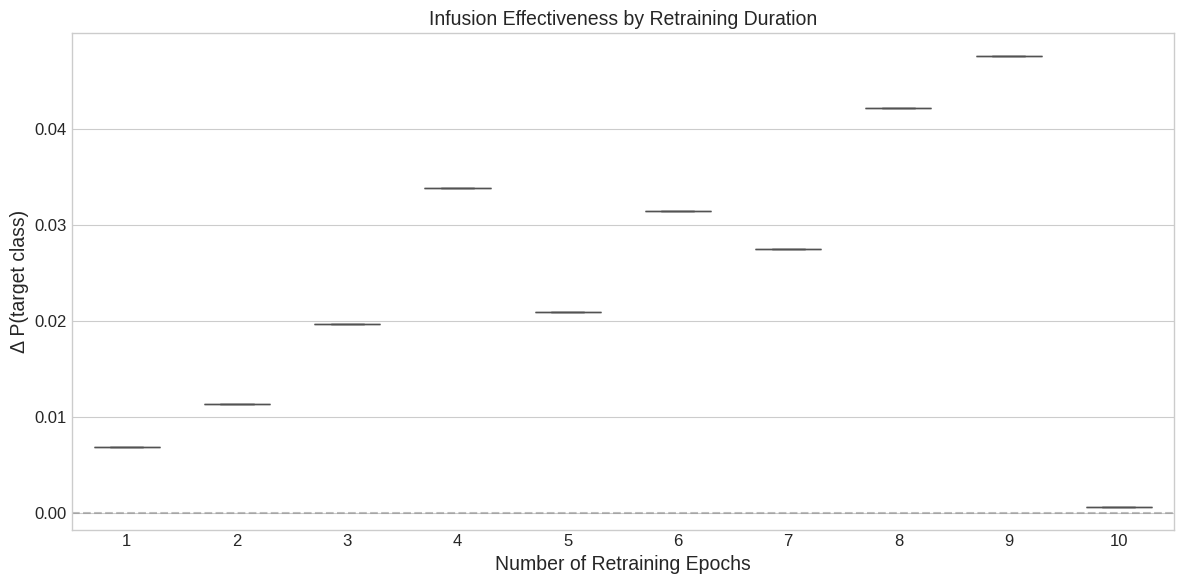

In [7]:
# Also create box plot version
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Sort by n_retrain_epochs for logical ordering
    order = sorted(df['n_retrain_epochs'].unique())
    
    sns.boxplot(
        data=df, 
        x='n_retrain_epochs', 
        y='delta_prob',
        order=order,
        ax=ax,
        color='#2563eb',
        width=0.6
    )
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Number of Retraining Epochs', fontsize=14)
    ax.set_ylabel('Δ P(target class)', fontsize=14)
    ax.set_title('Infusion Effectiveness by Retraining Duration', fontsize=14)
    
    plt.tight_layout()
    
    
    plt.savefig('figures/retrain_ablation_boxplot.png', dpi=150, bbox_inches='tight')
    print(f"Saved figure")
    
    plt.show()